In [61]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [62]:
from scipy.signal import hilbert
def as_signal_list(signals):
    if isinstance(signals, np.ndarray) and signals.ndim == 2:
        return [np.asarray(row, dtype=float) for row in signals]
    return [np.asarray(s, dtype=float) for s in signals]


class GaussianLoglike:
    def __init__(self, data, sigma=1.0):
        self.data = as_signal_list(data)
        self.sigma = sigma

    def loglike(self, signals):
        signals = as_signal_list(signals)
        total = sum(np.sum((x - ref) ** 2) for x, ref in zip(signals, self.data))
        return -0.5 * total / self.sigma ** 2

class WassersteinLoglikeLinear:
    def __init__(self, data, lam=1.0, n_sensors=1, n_quantiles=200):
        self.lam = lam
        self.n_sensors = n_sensors
        self.n_quantiles = n_quantiles
        self.data = np.asarray(data, dtype=float)
 
    def _normalize(self, x, ref):
        shift = -min(0.0, x.min(), ref.min())
        shifted = x + shift
        return shifted / shifted.sum()
 
    def _quantile_function(self, density):
        cdf = np.cumsum(density)
        cdf = cdf / cdf[-1]
        t = np.arange(len(density), dtype=float)
        u = (np.arange(self.n_quantiles) + 0.5) / self.n_quantiles
        return np.interp(u, cdf, t)
 
    def loglike(self, x):
        x = np.asarray(x, dtype=float)
        total = 0.0
        for i in range(self.n_sensors):
            xv, dv = x[i::self.n_sensors], self.data[i::self.n_sensors]
            pn, qn = self._normalize(xv, dv), self._normalize(dv, xv)
            Fx, Fd = self._quantile_function(pn), self._quantile_function(qn)
            total += np.sum((Fx - Fd) ** 2) / self.n_quantiles
        return -self.lam * total
 
 
class WassersteinLoglike:
    def __init__(self, data, lam=1.0, n_sensors=1, c=None, n_quantiles=200):
        self.lam = lam
        self.n_sensors = n_sensors
        self.n_quantiles = n_quantiles
        self.data = np.asarray(data, dtype=float)
        self.c = c
 
    def _normalize(self, x, ref):
        if self.c is not None:
            c = self.c
        else:
            c = -min(0.0, x.min(), ref.min())
            if c == 0.0:
                c = 1.0 
        pos = x >= 0
        raw = np.where(pos, x + 1.0 / c, (1.0 / c) * np.exp(c * x))
        return raw / raw.sum()
 
    def _quantile_function(self, density):
        cdf = np.cumsum(density)
        cdf = cdf / cdf[-1]
        t = np.arange(len(density), dtype=float)
        u = (np.arange(self.n_quantiles) + 0.5) / self.n_quantiles
        return np.interp(u, cdf, t)
 
    def loglike(self, x):
        x = np.asarray(x, dtype=float)
        total = 0.0
        for i in range(self.n_sensors):
            xv, dv = x[i::self.n_sensors], self.data[i::self.n_sensors]
            pn, qn = self._normalize(xv, dv), self._normalize(dv, xv)
            Fx, Fd = self._quantile_function(pn), self._quantile_function(qn)
            total += np.sum((Fx - Fd) ** 2) / self.n_quantiles
        return -self.lam * total

class WassersteinLoglikeSoftplus:
    def __init__(self, data, lam=1.0, n_sensors=1, c=None, n_quantiles=200):
        self.lam = lam
        self.n_sensors = n_sensors
        self.n_quantiles = n_quantiles
        self.data = np.asarray(data, dtype=float)
        self.c = c

    @staticmethod
    def _softplus(z):
        return np.maximum(z, 0) + np.log1p(np.exp(-np.abs(z)))

    def _normalize(self, x, ref):
        if self.c is not None:
            c = self.c
        else:
            c = -min(0.0, x.min(), ref.min())
            if c == 0.0:
                c = 1.0
        raw = self._softplus(c * x)
        return raw / raw.sum()

    def _quantile_function(self, density):
        cdf = np.cumsum(density)
        cdf = cdf / cdf[-1]
        t = np.arange(len(density), dtype=float)
        u = (np.arange(self.n_quantiles) + 0.5) / self.n_quantiles
        return np.interp(u, cdf, t)

    def loglike(self, x):
        x = np.asarray(x, dtype=float)
        total = 0.0
        for i in range(self.n_sensors):
            xv, dv = x[i::self.n_sensors], self.data[i::self.n_sensors]
            pn, qn = self._normalize(xv, dv), self._normalize(dv, xv)
            Fx, Fd = self._quantile_function(pn), self._quantile_function(qn)
            total += np.sum((Fx - Fd) ** 2) / self.n_quantiles
        return -self.lam * total

class WassersteinLoglikeEnvelope:
    def __init__(self, data, lam=1.0, n_sensors=1, c=None, n_quantiles=200):
        self.lam = lam
        self.n_sensors = n_sensors
        self.n_quantiles = n_quantiles
        self.data = np.asarray(data, dtype=float)
        self.c = c

    def _envelope(self, x):
        return np.abs(hilbert(x))

    def _density(self, x):
        e = self._envelope(x)
        c = self.c if self.c is not None else 1.0
        raw = np.exp(c * e)
        return raw / raw.sum()

    def _quantile_function(self, density):
        cdf = np.cumsum(density)
        cdf = cdf / cdf[-1]
        t = np.arange(len(density), dtype=float)
        u = (np.arange(self.n_quantiles) + 0.5) / self.n_quantiles
        return np.interp(u, cdf, t)

    def loglike(self, x):
        x = np.asarray(x, dtype=float)
        total = 0.0
        for i in range(self.n_sensors):
            xv, dv = x[i::self.n_sensors], self.data[i::self.n_sensors]
            p, q = self._density(xv), self._density(dv)
            Fx, Fd = self._quantile_function(p), self._quantile_function(q)
            total += np.sum((Fx - Fd) ** 2) / self.n_quantiles
        return -self.lam * total

In [63]:
def synthetic_pressure_signal(t, source_x, sensor_x, H=1.5, c=1.0,
                               amplitude=1.0, n_cycles=10.0,
                               sigma_noise=0.0, seed=None):
    rng = np.random.default_rng(seed)
    R = abs(sensor_x - source_x)
    t0 = R / c
    f_res = c / (4 * H)
    envelope_width = (n_cycles / f_res) / 2

    envelope = np.exp(-0.5 * ((t - t0) / envelope_width) ** 2)
    carrier = np.sin(2 * np.pi * f_res * (t - t0))
    amp = amplitude / np.sqrt(1 + R)

    signal = amp * envelope * carrier
    if sigma_noise > 0:
        signal = signal + rng.normal(0, sigma_noise, size=len(t))
    return signal

def synthetic_multi_sensor(t, source_x, sensors, **kwargs):
    n_sensors = len(sensors)
    seed = kwargs.pop("seed", None)
    signals = [synthetic_pressure_signal(t, source_x, sx, seed=(None if seed is None else seed + i), **kwargs)
               for i, (sx, _sz) in enumerate(sensors)]
    out = np.empty(len(t) * n_sensors)
    for i, s in enumerate(signals):
        out[i::n_sensors] = s
    return out

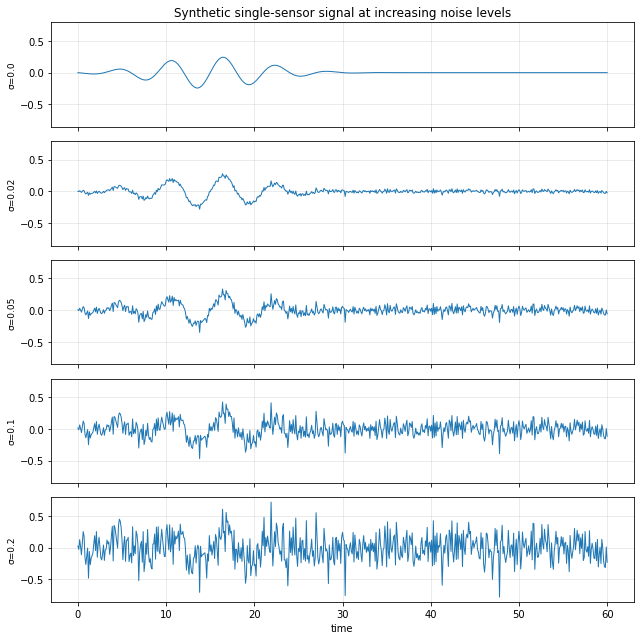

In [64]:
H, TEnd, nt = 1.5, 60, 601
t = np.linspace(0, TEnd, nt)
sensor_x, x0_true = 15.0, 0.0
n_cycles = 2.0

d_true = synthetic_pressure_signal(t, x0_true, sensor_x, H=H, n_cycles=n_cycles)

noise_levels_demo = [0.0, 0.02, 0.05, 0.1, 0.2]
fig, axes = plt.subplots(len(noise_levels_demo), 1, figsize=(9, 1.8*len(noise_levels_demo)),
                          sharex=True, sharey=True)
for ax, sigma in zip(axes, noise_levels_demo):
    s = synthetic_pressure_signal(t, x0_true, sensor_x, H=H, n_cycles=n_cycles,
                                   sigma_noise=sigma, seed=0)
    ax.plot(t, s, lw=1)
    ax.set_ylabel(f"σ={sigma}", fontsize=9)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("time")
axes[0].set_title("Synthetic single-sensor signal at increasing noise levels")
plt.tight_layout()
plt.show()

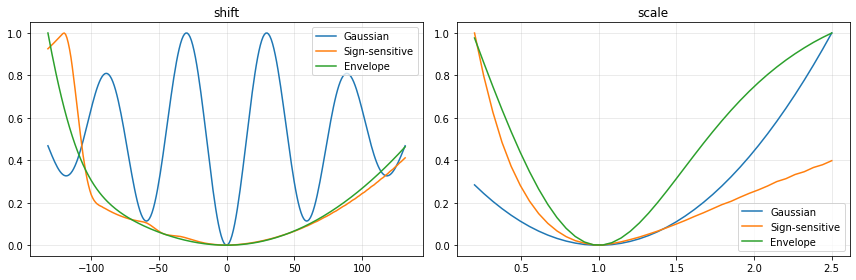

In [73]:
def split(d, n): return [d[i::n] for i in range(n)]
def interleave(ps):
    out = np.empty(len(ps[0])*len(ps))
    for i, p in enumerate(ps): out[i::len(ps)] = p
    return out

def adaptive_c(data, c_reference, reference_signal):
    target_ratio = np.exp(c_reference * np.abs(reference_signal).max())
    return np.log(target_ratio) / np.abs(data).max()

def plot_robustness(data, n_sensors=1, lam=400.0, c_ss=None, b_softplus=None, c_envelope=None):
    parts = split(data, n_sensors)
    cands = {"Gaussian": GaussianLoglike(parts, sigma=1/np.sqrt(lam)),
             #"Linear": WassersteinLoglikeLinear(data, lam, n_sensors),
             "Sign-sensitive": WassersteinLoglike(data, lam, n_sensors, c=c_ss),
             #"Softplus": WassersteinLoglikeSoftplus(data, lam, n_sensors, b=b_softplus),
             "Envelope": WassersteinLoglikeEnvelope(data, lam, n_sensors, c=c_envelope)}
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    period_samples = int(4 * H / (TEnd / (nt - 1)))  # samples per carrier period
    max_shift = int(2.2 * period_samples)  # span past 1 full period, not just a fraction
    for xs, mode, a in [(np.arange(-max_shift, max_shift + 1), "shift", ax[0]), (np.linspace(0.2, 2.5, 40), "scale", ax[1])]:
        for name, m in cands.items():
            mods = [[np.roll(s, v) if mode == "shift" else v*s for s in parts] for v in xs]
            vals = np.array([-m.loglike(mod if isinstance(m, GaussianLoglike) else interleave(mod)) for mod in mods])
            a.plot(xs, vals/(vals.max() or 1), label=name)
        a.legend(); a.set_title(mode); a.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

plot_robustness(d_true, n_sensors=1, c_ss=80, b_softplus=40, c_envelope=10)

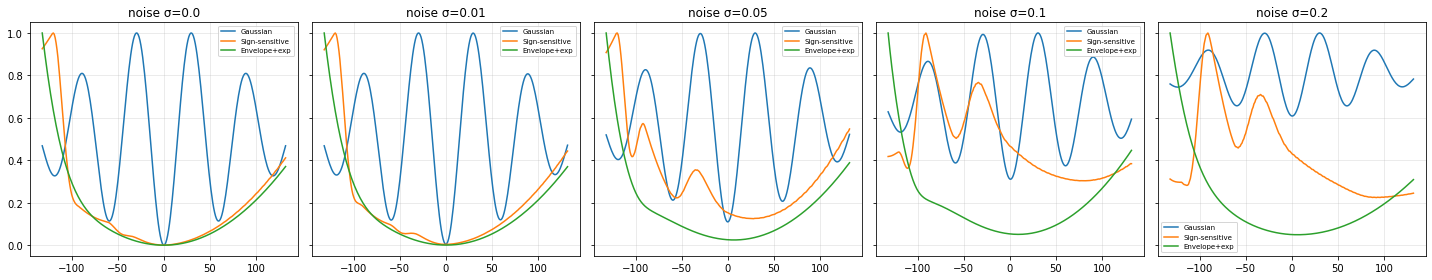

In [71]:
def shift_robustness_noise(data, noise_levels=(0.0, 0.01, 0.05, 0.5), n_sensors=1, lam=400.0, max_shift=None, c_ss=None, b_softplus=None, c_envelope=None, seed=0):
    rng = np.random.default_rng(seed)
    if max_shift is None:
        period_samples = int(4 * H / (TEnd / (nt - 1)))
        max_shift = int(2.2 * period_samples)  # span past 1 full period by default
    shifts = np.arange(-max_shift, max_shift+1)
    clean_parts = split(data, n_sensors)
    fig, axes = plt.subplots(1, len(noise_levels), figsize=(4*len(noise_levels), 4), sharey=True)
    for sigma, ax in zip(noise_levels, axes):
        noisy = data + rng.normal(0, sigma, data.shape)  # noisy "observed" reference
        cands = {"Gaussian": GaussianLoglike(split(noisy, n_sensors), sigma=1/np.sqrt(lam)),
                 #"Linear": WassersteinLoglikeLinear(noisy, lam, n_sensors),
                 "Sign-sensitive": WassersteinLoglike(noisy, lam, n_sensors,
                                           c=adaptive_c(noisy, c_ss, data) if c_ss is not None else None),
                 #"Softplus": WassersteinLoglikeSoftplus(noisy, lam, n_sensors, b=b_softplus),
                 "Envelope+exp": WassersteinLoglikeEnvelope(noisy, lam, n_sensors, c=c_envelope)}
        for name, m in cands.items():
            mods = [[np.roll(s, v) for s in clean_parts] for v in shifts] 
            vals = np.array([-m.loglike(mod if name == "Gaussian" else interleave(mod)) for mod in mods])
            ax.plot(shifts, vals/(vals.max() or 1), label=name)
        ax.set_title(f"noise σ={sigma}")
        ax.legend(fontsize=7); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

shift_robustness_noise(d_true, noise_levels=(0.0, 0.01, 0.05, 0.1, 0.2), n_sensors=1, c_ss=80, b_softplus=40, c_envelope=20)

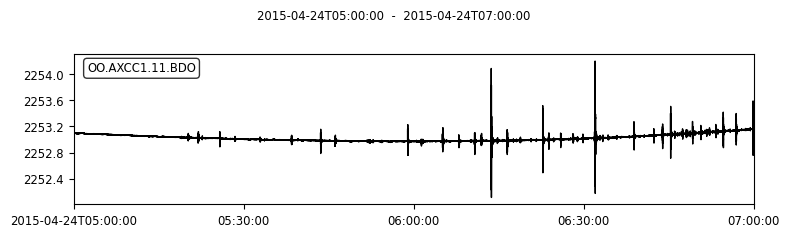

               network: OO
               station: AXCC1
              location: 11
               channel: BDO
             starttime: 2015-04-24T05:00:00.000000Z
               endtime: 2015-04-24T06:25:06.200000Z
         sampling_rate: 20.0
                 delta: 0.05
                  npts: 102125
                 calib: 1.0
_fdsnws_dataselect_url: https://service.earthscope.org/fdsnws/dataselect/1/query
               _format: MSEED
                 mseed: AttribDict({'dataquality': 'M', 'number_of_records': 897, 'encoding': 'FLOAT32', 'byteorder': '>', 'record_length': 512, 'filesize': 647168})
            processing: ['ObsPy 1.5.0: trim(endtime=UTCDateTime(2015, 4, 24, 7, 0)::fill_value=None::nearest_sample=True::pad=False::starttime=UTCDateTime(2015, 4, 24, 5, 0))']


In [31]:
from obspy.clients.fdsn import Client
from obspy import UTCDateTime

client = Client("EARTHSCOPE")

#st = client.get_waveforms(network="OO", station="AXCC1", location="*",
#                           channel="HDH",
#                           starttime=UTCDateTime("2015-04-24T05:00:00"),
#                           endtime=UTCDateTime("2015-04-24T07:00:00"))

st_bdo = client.get_waveforms(network="OO", station="AXCC1", location="11",
                               channel="BDO",
                               starttime=UTCDateTime("2015-04-24T05:00:00"),
                               endtime=UTCDateTime("2015-04-24T07:00:00"))

st_bdo.plot()
print(st_bdo[0].stats)

npts: 1201  dt: 0.05  duration: 60.050000000000004


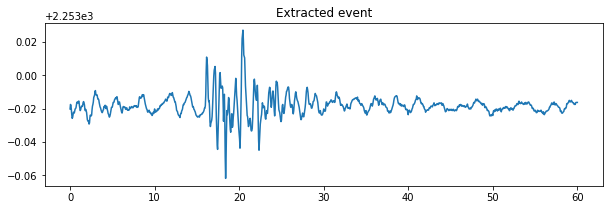

In [42]:
tr = st_bdo[0]

window_seconds = 60
start_time = UTCDateTime("2015-04-24T06:15:00")
event_time = start_time - window_seconds / 2

tr_event = tr.copy()
tr_event.trim(starttime=event_time, endtime=event_time + window_seconds)

d_real = tr_event.data.astype(float)
dt_real = tr_event.stats.delta
print("npts:", len(d_real), " dt:", dt_real, " duration:", len(d_real)*dt_real)

plt.figure(figsize=(10, 3))
plt.plot(np.arange(len(d_real))*dt_real, d_real)
plt.title("Extracted event")
plt.show()

npts: 1201  dt: 0.05  duration: 60.050000000000004
peak amplitude after detrend: 0.045042216777801514


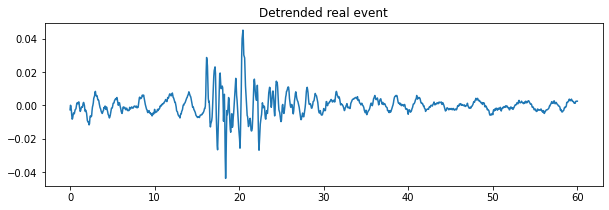

In [75]:
tr_event = tr.copy()
tr_event.trim(starttime=start_time - window_seconds/2,
              endtime=start_time + window_seconds/2)

tr_event.detrend("linear")
tr_event.detrend("demean")

d_real = tr_event.data.astype(float)
dt_real = tr_event.stats.delta

print("npts:", len(d_real), " dt:", dt_real, " duration:", len(d_real)*dt_real)
print("peak amplitude after detrend:", np.abs(d_real).max())

plt.figure(figsize=(10,3))
plt.plot(np.arange(len(d_real))*dt_real, d_real)
plt.title("Detrended real event")
plt.show()

In [76]:
H, TEnd, nt = None, len(d_real)*dt_real, len(d_real) 
t = np.arange(nt)*dt_real
d_true = d_real

freqs = np.fft.rfftfreq(len(d_real), dt_real)
spec = np.abs(np.fft.rfft(d_real))
peak_freq = freqs[np.argmax(spec[1:])+1]
est_period = 1/peak_freq
H = est_period/4
print(f"estimated dominant period: {est_period:.2f} s -> using H={H:.2f}")

estimated dominant period: 2.50 s -> using H=0.63


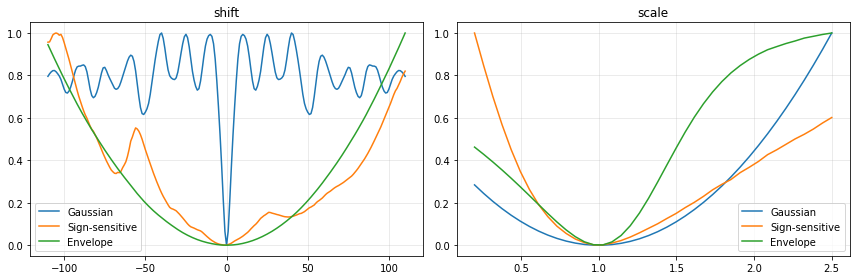

In [77]:
plot_robustness(d_true, n_sensors=1, c_ss=c_guess, b_softplus=c_guess/2, c_envelope=100)

noise levels (real units): (0.0, 0.0045042216777801515, 0.009008443355560303)


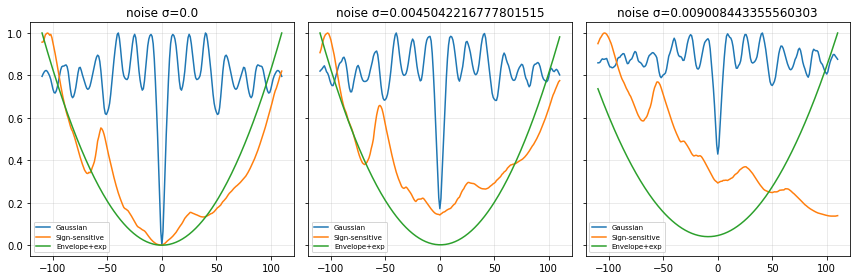

In [80]:
noise_fracs = (0.0, 0.1, 0.2)
noise_levels_real = tuple(f*peak for f in noise_fracs)
print("noise levels (real units):", noise_levels_real)

shift_robustness_noise(d_true, noise_levels=noise_levels_real, n_sensors=1,
                        c_ss=c_guess, b_softplus=c_guess/2, c_envelope=c_guess)